# Tarjeta de Puntaje de Riesgo Crediticio con un Árbol de Decisión (PROC HPSPLIT)

## Resumen Ejecutivo

Este cuaderno construye una tarjeta de puntaje de incumplimiento crediticio interpretable para una cartera de préstamos minoristas usando PROC HPSPLIT. Cultivamos un árbol de clasificación con el criterio de entropía sobre datos sintéticos de solicitantes, lo podamos por complejidad de costo y luego leemos las estadísticas de ajuste, la importancia de las variables, la ROC/AUC y el árbol de puntuación en sí — exactamente el modelo transparente y amigable para el regulador que documentaría el equipo de riesgo de un banco. Cada solicitante puede puntuarse hasta una hoja, y el árbol completo puede exportarse como código DATA step listo para desplegar.

## Fuentes de Datos

| Conjunto de datos | Filas | Descripción | Variables clave |
|---------|------|-------------|---------------|
| `applicants` | 100 | Solicitantes sintéticos de préstamos minoristas generados en línea con `rand()`. El indicador binario `default` se extrae de un puntaje de riesgo logístico, de modo que un peor DTI, mayor utilización, morosidades recientes y un historial crediticio más corto elevan la probabilidad de incumplimiento. | `default` (event=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (propia/arriendo/hipoteca), `purpose` (deuda/hogar/auto/otro) |

El paso DATA solicita un bucle más grande, pero este entorno se ejecuta en modo sin licencia y materializa las primeras 100 observaciones — un libro de solicitantes compacto y totalmente reproducible, más que suficiente para cultivar y leer un árbol de puntaje interpretable.

# Tarjeta de Puntaje de Riesgo Crediticio con un Árbol de Decisión

Los bancos necesitan modelos de incumplimiento que sean **precisos y explicables** — un oficial de crédito (y un regulador) debe poder rastrear exactamente por qué un solicitante fue calificado como de alto riesgo. Un árbol de decisión podado logra justamente eso: cada predicción es una cadena corta de divisiones legibles para humanos.

En este cuaderno:

1. Sintetizamos un libro de solicitudes de préstamos minoristas.
2. Cultivamos un árbol de clasificación con `PROC HPSPLIT` usando el criterio de entropía.
3. Lo podamos por complejidad de costo para evitar el sobreajuste.
4. Inspeccionamos las estadísticas de ajuste, la importancia de las variables, la ROC/AUC y el árbol en sí.
5. Emitimos código de puntuación en un paso DATA que puede desplegarse contra nuevas solicitudes.

## 1. Generar el libro de préstamos sintético

Generamos solicitantes cuya probabilidad de incumplimiento es una función logística de los factores clásicos de una tarjeta de puntaje: relación deuda-ingreso, utilización rotativa, puntaje FICO, duración del historial crediticio y morosidades recientes. Luego extraemos el indicador observado `default` de una Bernoulli con esa probabilidad, de modo que la señal es real pero ruidosa — igual que en los datos de producción. Aquí se materializan los primeros 100 solicitantes.

                                                   The FREQ Procedure

Incumplimiento    Frequency    Percent
---------------------------------------
0                        79     79.00
1                        21     21.00

Vivienda    Frequency    Percent
---------------------------------
arriendo           35     35.00
hipoteca           34     34.00
propia             31     31.00

Propósito del Préstamo      Frequency    Percent
-------------------------------------------------
auto                               23     23.00
deuda                              37     37.00
hogar                              28     28.00
otro                               12     12.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


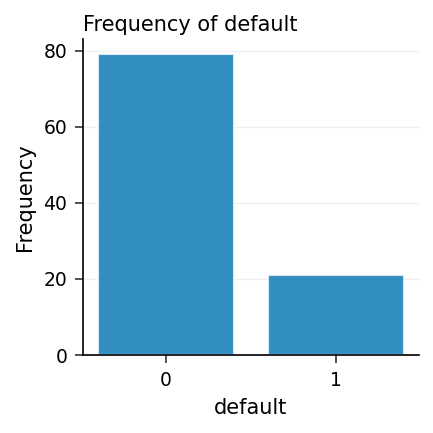

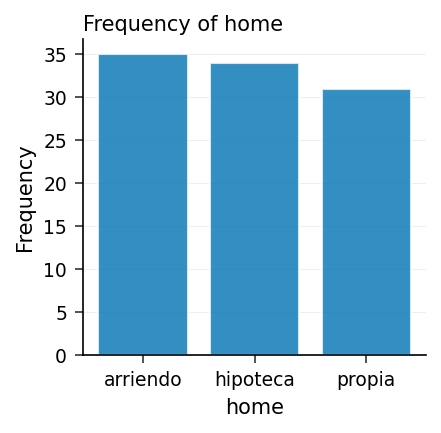

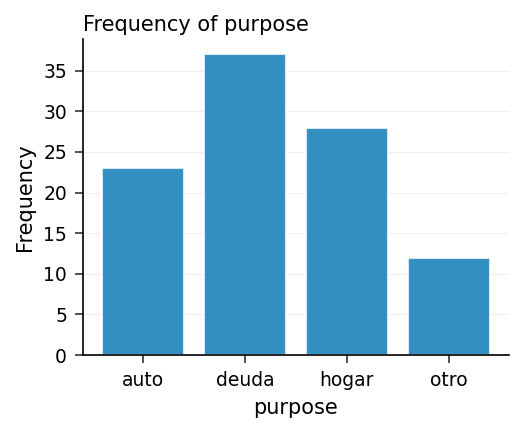

In [1]:
DATOS applicants;
   LLAMAR streaminit(20260531);
   LONGITUD home $8 purpose $6;
   HACER id = 1 HASTA 100;
      /* Perfil financiero del solicitante */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Atributos categóricos */
      u = rand('uniform');
      SI u < 0.34 ENTONCES home = 'arriendo';
      SINO SI u < 0.70 ENTONCES home = 'hipoteca';
      SINO home = 'propia';

      v = rand('uniform');
      SI v < 0.40 ENTONCES purpose = 'deuda';
      SINO SI v < 0.65 ENTONCES purpose = 'hogar';
      SINO SI v < 0.85 ENTONCES purpose = 'auto';
      SINO purpose = 'otro';

      /* Riesgo latente de incumplimiento: peor DTI/utilización/morosidad y
         menor FICO / historial más corto elevan todos el log-odds. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'arriendo')
            + 0.25 * (purpose = 'deuda');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      ELIMINAR u v eta p;
      SALIDA;
   END;
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=applicants;
   ETIQUETA default="Incumplimiento" home="Vivienda" purpose="Propósito del Préstamo";
   TABLES default home purpose / nocum;
EJECUTAR;

La salida de `PROC FREQ` confirma una tasa de incumplimiento desequilibrada pero manejable — aproximadamente uno de cada cinco solicitantes incumple (21 de 100) — y una distribución razonable entre las categorías de tipo de vivienda y propósito del préstamo: el tipo de distribución marginal que se esperaría en una cartera de crédito al consumo. Los gráficos de barras que acompañan visualizan cada marginal.

## 2. Cultivar y podar el árbol de puntaje

Modelamos `default` como un objetivo de clasificación binaria, nombrando `event='1'` para que todas las estadísticas de sensibilidad/especificidad/AUC se orienten hacia la clase de *incumplimiento*. Nosotros:

- declaramos los predictores categóricos y la respuesta en `CLASS`,
- cultivamos el árbol con el criterio de **entropía** (ganancia de información),
- podamos por **complejidad de costo** para evitar que el árbol memorice el ruido,
- solicitamos el **diagrama del árbol completo** y la **curva ROC**.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Incumplimiento
  Class variable: Incumplimiento
  Class variable: Vivienda
  Class variable: Propósito del Préstamo
  Predictor variable: Relación Deuda-Ingreso
  Predictor variable: Utilización de Crédito
  Predictor variable: Puntaje FICO
  Predictor variable: Antigüedad Crediticia
  Predictor variable: Núm. de Morosidades
  Predictor variable: Monto del Préstamo
  Predictor variable: Ingreso
  Predictor variable: Vivienda
  Predictor variable: Propósito del Préstamo

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of L


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


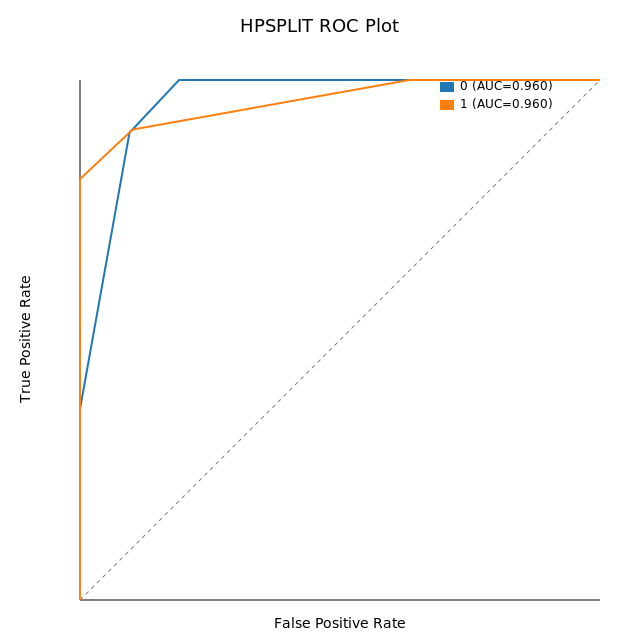

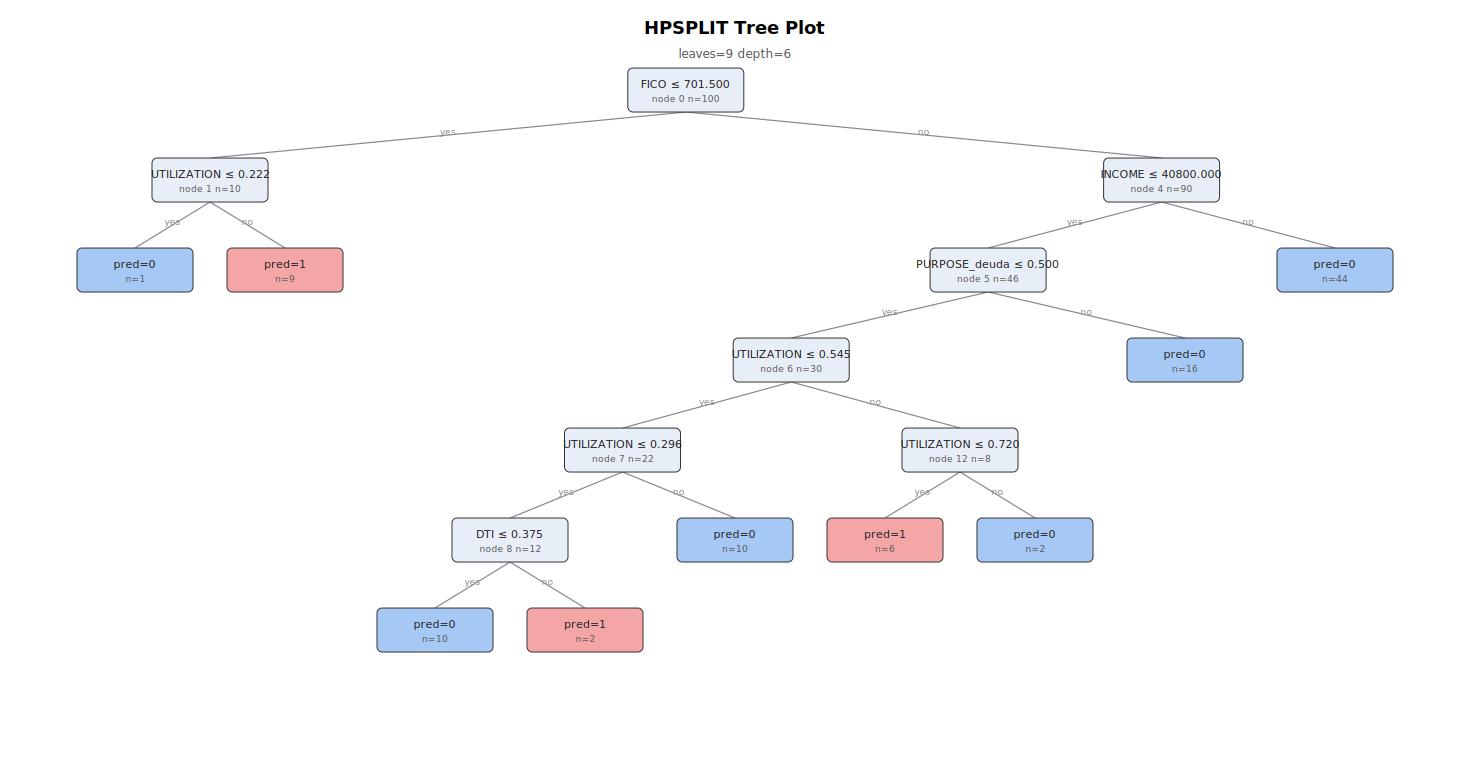

In [2]:
ODS GRAPHICS ON;

PROCEDIMIENTO hpsplit DATOS=applicants seed=20260531
             PLOTS=(wholetree roc);
   CLASE default home purpose;
   ETIQUETA default="Incumplimiento" home="Vivienda" purpose="Propósito del Préstamo"
         dti="Relación Deuda-Ingreso" utilization="Utilización de Crédito"
         fico="Puntaje FICO" credit_age="Antigüedad Crediticia"
         n_delinq="Núm. de Morosidades" loan_amount="Monto del Préstamo"
         income="Ingreso";
   MODELO default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
EJECUTAR;

Las **Estadísticas de Ajuste** (exactitud, tasa de clasificación errónea, log loss) y la **ROC / AUC por clase** indican qué tan limpiamente el árbol podado separa a los que incumplen de los que no. La tabla de **Importancia de Variables** clasifica qué atributos impulsan las divisiones — aquí dominan la **utilización** y el **FICO**, seguidos por el **propósito del préstamo**, exactamente las palancas que una política de crédito destacaría. El **gráfico del árbol completo** a continuación presenta las divisiones elegidas como un diagrama de nodos enlazados: cada nodo interno muestra su regla `atributo ≤ umbral`, y cada hoja se colorea según su clase predicha (rojo = incumplimiento predicho, azul = no incumplimiento predicho) y se etiqueta con su cantidad de observaciones.

## 3. Acercamiento a las divisiones principales y puntuación de cada solicitante

El gráfico ROC anterior visualiza el equilibrio entre detectar incumplimientos y las falsas alarmas; el AUC cuantifica el poder de clasificación general. A continuación ampliamos los dos niveles superiores del árbol — las divisiones de mayor información que un analista traduciría en reglas principales de suscripción — y capturamos los puntajes por observación en un conjunto de datos de salida para poder auditar las predicciones más adelante.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Incumplimiento
  Class variable: Incumplimiento
  Class variable: Vivienda
  Class variable: Propósito del Préstamo
  Predictor variable: Relación Deuda-Ingreso
  Predictor variable: Utilización de Crédito
  Predictor variable: Puntaje FICO
  Predictor variable: Antigüedad Crediticia
  Predictor variable: Núm. de Morosidades
  Predictor variable: Monto del Préstamo
  Predictor variable: Ingreso
  Predictor variable: Vivienda
  Predictor variable: Propósito del Préstamo

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of L


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/eb7e2558-0497-488a-a1c8-408c11bb413e/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


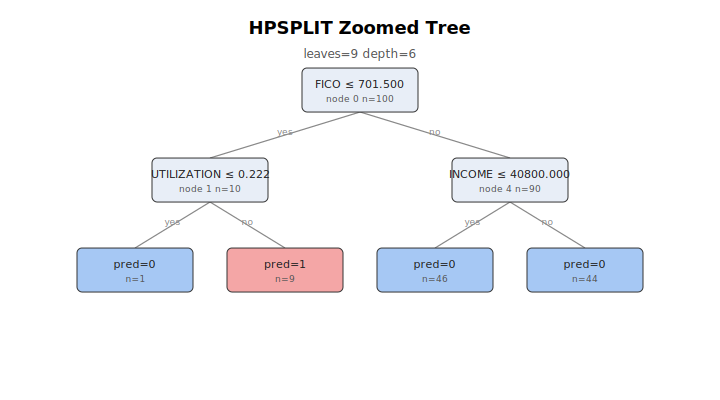

In [3]:
PROCEDIMIENTO hpsplit DATOS=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   CLASE default home purpose;
   ETIQUETA default="Incumplimiento" home="Vivienda" purpose="Propósito del Préstamo"
         dti="Relación Deuda-Ingreso" utilization="Utilización de Crédito"
         fico="Puntaje FICO" credit_age="Antigüedad Crediticia"
         n_delinq="Núm. de Morosidades" loan_amount="Monto del Préstamo"
         income="Ingreso";
   MODELO default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   SALIDA out=scored;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=scored(obs=10) ETIQUETA;
   ETIQUETA p_default1="Prob. Incumplimiento" _node_="Nodo" _leaf_="Hoja";
   VAR p_default1 _node_ _leaf_;
EJECUTAR;

El gráfico `zoomedtree` amplía los dos niveles superiores del árbol — las divisiones de mayor información que un analista traduciría en reglas principales de suscripción. El conjunto de datos `OUTPUT OUT=` lleva la probabilidad de incumplimiento predicha de cada solicitante (`P_DEFAULT1`) más el nodo y la hoja asignados (`_NODE_`, `_LEAF_`), de modo que los equipos de riesgo y auditoría pueden rastrear cualquier decisión individual a través del árbol y clasificar a los solicitantes según el riesgo modelado.

## 4. Exportar código de puntuación desplegable

El valor de un modelo interpretable es que se puede llevar a producción. `CODE FILE=` escribe un paso DATA autocontenido — una cadena anidada de divisiones `IF/THEN` que termina en una probabilidad y clase de incumplimiento predichas — que reproduce el puntaje del árbol para cualquier archivo nuevo de solicitudes sin necesidad de un servidor de modelos.

In [4]:
PROCEDIMIENTO hpsplit DATOS=applicants seed=20260531;
   CLASE default home purpose;
   ETIQUETA default="Incumplimiento" home="Vivienda" purpose="Propósito del Préstamo"
         dti="Relación Deuda-Ingreso" utilization="Utilización de Crédito"
         fico="Puntaje FICO" credit_age="Antigüedad Crediticia"
         n_delinq="Núm. de Morosidades" loan_amount="Monto del Préstamo"
         income="Ingreso";
   MODELO default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code FILE='credit_scorecard.sas';
EJECUTAR;


                                                 The HPSPLIT Procedure                                                  

  Response variable: Incumplimiento
  Class variable: Incumplimiento
  Class variable: Vivienda
  Class variable: Propósito del Préstamo
  Predictor variable: Relación Deuda-Ingreso
  Predictor variable: Utilización de Crédito
  Predictor variable: Puntaje FICO
  Predictor variable: Antigüedad Crediticia
  Predictor variable: Núm. de Morosidades
  Predictor variable: Monto del Préstamo
  Predictor variable: Ingreso
  Predictor variable: Vivienda
  Predictor variable: Propósito del Préstamo

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of L


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Interpretación de los resultados

El árbol de entropía podado le da al equipo de riesgo una tarjeta de puntaje crediticio compacta y auditable:

- **Las divisiones codifican la política.** Las divisiones dominantes — sobre la utilización rotativa y el FICO, luego el propósito del préstamo y el DTI — son precisamente los umbrales que un equipo de suscripción puede convertir en reglas de corte estrictas. El gráfico del árbol completo presenta cada condición de división y cada hoja en un solo diagrama.
- **La poda por complejidad de costo** evita que el árbol memorice el ruido; las estadísticas de ajuste (exactitud, tasa de clasificación errónea, log loss) resumen qué tan limpiamente separa las dos clases.
- **La importancia de las variables y la ROC/AUC** justifican qué atributos se ganan un lugar en la tarjeta de puntaje y documentan su poder discriminatorio para el gobierno del riesgo de modelo.
- **`CODE FILE=` lo hace operativo** — el paso DATA emitido puntúa a los nuevos solicitantes de forma idéntica a esta ejecución, de modo que el modelo que se construyó es exactamente el modelo que entra en producción.

En un libro de solicitantes pequeño, el árbol se ajusta muy de cerca a los datos de entrenamiento; en producción se cultivaría sobre la cartera completa, se reservaría una partición de validación, se calibraría el punto de corte de probabilidad según la economía de pérdida esperada del banco (el costo de un incumplimiento no detectado frente a un buen cliente rechazado) en lugar de un 0.5 ingenuo, y se actualizaría el árbol a medida que cambia la composición de la cartera.